# LogPress

### Data Loading

Load all log datasets and examine their formats.

In [1]:
# Library imports
import re # Import regex module for pattern matching (used for semantic type detection)
import time # Import time module to measure execution duration of operations
from pathlib import Path # Import Path class for datasets path handling
from collections import Counter # Import Counter for counting token frequencies
from datetime import datetime # Import datetime for timestamp parsing and conversion

# Try to import all required libraries - if any fail, install them
try:
    import pandas as pd # pandas: Data manipulation and CSV export functionality
    import matplotlib.pyplot as plt  # matplotlib: Creating charts and visualizations
    import numpy as np # numpy: Numerical operations and array handling
    import gzip # gzip: Standard compression algorithm (baseline comparison)
    import bz2 # bz2: Bzip2 compression (baseline comparison)
    import lzma # lzma: LZMA compression (baseline comparison)
    import msgpack # msgpack: Binary serialization format    
    import zstandard as zstd  # zstandard: Facebook's Zstd compression

# If any import fails, install missing packages and retry
except ImportError:
    print("Installing dependencies...") # Notify that we're installing dependencies
    %pip install pandas numpy matplotlib msgpack zstandard # Use pip magic command to install required packages

    # Retry imports after installation
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    import msgpack
    import zstandard as zstd

# Create tables directory for CSV exports
TABLES_DIR = Path("tables") # Create "tables" directory to store CSV output files
TABLES_DIR.mkdir(exist_ok=True) # Don't error if directory already exists

print("All libraries loaded.") # Confirm successful library loading
print(f"Tables will be saved to: {TABLES_DIR}/") # Show where CSV files will be saved

All libraries loaded.
Tables will be saved to: tables/


In [ ]:
# Dataset paths
DATASETS_DIR = Path("datasets") # Path to datasets directory


# Dictionary mapping dataset names to their file paths
DATASET_FILES = {
    "Apache": DATASETS_DIR / "Apache.log", # Apache web server logs
#    "BGL": DATASETS_DIR / "BGL.log", # commented out cause the local setup could not handle the amount of data
    "Hadoop": DATASETS_DIR / "Hadoop.log", # Hadoop Logs
#    "HDFS": DATASETS_DIR / "HDFS.log", # commented out cause the local setup could not handle the amount of data
    "HealthApp": DATASETS_DIR / "HealthApp.log", # Mobile Health application logs
    "Linux": DATASETS_DIR / "Linux.log", # Linux system logs
    "Mac": DATASETS_DIR / "Mac.log", # macOS system logs
  #  "OpenSSH": DATASETS_DIR / "OpenSSH.log", # OpenSSH server logs
    "Openstack": DATASETS_DIR / "Openstack.log", # OpenStack cloud computing logs
 #   "Spark": DATASETS_DIR / "Spark.log", # commented out cause the local setup could not handle the amount of data
    "Proxifier": DATASETS_DIR / "Proxifier.log", # Proxy application logs
    "Zookeeper": DATASETS_DIR / "Zookeeper.log", # Apache ZooKeeper coordination logs
    "SSH": DATASETS_DIR / "SSH.log", # SSH logs

}

# Verify each dataset file exists before processing
for name, path in DATASET_FILES.items():
    if path.exists():  # Check if file exists on disk
        print(f"{name}: {path} (EXISTS)") # File found - print confirmation with EXISTS status
    else:
        print(f"{name}: {path} (MISSING)") # File missing - print warning with MISSING status


Apache: datasets/Apache.log (EXISTS)
Hadoop: datasets/Hadoop.log (EXISTS)
HealthApp: datasets/HealthApp.log (EXISTS)
Linux: datasets/Linux.log (EXISTS)
Mac: datasets/Mac.log (EXISTS)
Openstack: datasets/Openstack.log (EXISTS)
Proxifier: datasets/Proxifier.log (EXISTS)
Zookeeper: datasets/Zookeeper.log (EXISTS)
SSH: datasets/SSH.log (EXISTS)


In [3]:
# Helper functions for data loading
def load_logs(filepath): # Function to read all log lines from each dataset file
    logs = [] # Initialize empty list to store log lines
    with open(filepath, "r", encoding="utf-8", errors="replace") as f: # Open file with UTF-8 encoding, replace invalid characters instead of crashing
        for line in f: # Read file line by line
            line = line.rstrip("\n\r") # Remove newline characters 
            if line:  # skip empty lines
                logs.append(line)
    return logs # Return list of all log lines


def get_file_size_mb(filepath): # Function to get datasets size in megabytes
    return filepath.stat().st_size / (1024 * 1024) # stat().st_size returns size in bytes, divide by 1024^2 for MB

In [4]:
# Load all datasets into memory
datasets = {} # Dictionary to store loaded datasets (name -> list of log strings)
dataset_stats = [] # List to collect statistics for each dataset

print("Loading datasets...\n") # Print message for loading progress
print(f"{'Dataset':<12} {'Lines':>12} {'Size (MB)':>12}") # Print table header containing dataset name, number of lines, and size in MB
print("-" * 40) # Print separator line

# Track totals across all datasets
total_lines = 0
total_size = 0



for name, path in DATASET_FILES.items(): # Iterate through each dataset file
    start = time.time() # Record start time to measure loading duration
    logs = load_logs(path) # Load all logs from the dataset files
    elapsed = time.time() - start # Calculate how long loading took
    
    size_mb = get_file_size_mb(path)  # Get dataset file size in megabytes
    datasets[name] = logs # Store loaded logs in datasets dictionary
    
    total_lines += len(logs) # Update total line count for all datasets 
    total_size += size_mb # Update total size in MB 
    
    dataset_stats.append({ # Collect stats for each dataset
        "Dataset": name,
        "Lines": len(logs),
        "Size (MB)": round(size_mb, 1)
    })
    
    print(f"{name:<12} {len(logs):>12,} {size_mb:>12.1f}") # Print dataset loading stats

print("-" * 40) # Print separator line
print(f"{'TOTAL':<12} {total_lines:>12,} {total_size:>12.1f}") # Print total stats header for all datasets
print("\nAll datasets loaded.") # Confirm all datasets have been loaded

# Save to CSV
dataset_stats.append({"Dataset": "TOTAL", "Lines": total_lines, "Size (MB)": round(total_size, 1)}) # Append total stats to dataset stats
df_datasets = pd.DataFrame(dataset_stats) # Convert to pandas DataFrame for easy CSV export
df_datasets.to_csv(TABLES_DIR / "dataset_loading_stats.csv", index=False) # Save dataset loading statistics to CSV
print(f"Saved to {TABLES_DIR}/dataset_loading_stats.csv") # Confirm csv Stats directory save location

Loading datasets...

Dataset             Lines    Size (MB)
----------------------------------------
Apache             51,978          4.7
Hadoop            179,993         30.4
HealthApp         253,395         22.4
Linux              25,567          2.2
Mac               117,283         16.1
Openstack         189,386         53.4
Proxifier          21,320          2.4
Zookeeper          74,273          9.9
SSH               655,147         70.0
----------------------------------------
TOTAL           1,568,342        211.6

All datasets loaded.
Saved to tables/dataset_loading_stats.csv


In [5]:
# Preview first 3 logs sample from each dataset we loaded
print("Log Format Samples\n") # Print section header

for name, logs in datasets.items(): # Iterate through each loaded dataset
    print(f"=== {name} ===")    # Print dataset name as section header
    for i in range(min(3, len(logs))): # Show the first 3 log lines or less if dataset has fewer lines
        # Get the log line and truncate if too long for display
        line = logs[i]
        if len(line) > 120: # Truncate long lines to keep output readable
            line = line[:120] + "..."
        print(f"  {line}") # Print the log line
    print() # Add blank line between datasets

Log Format Samples

=== Apache ===
  [Thu Jun 09 06:07:04 2005] [notice] LDAP: Built with OpenLDAP LDAP SDK
  [Thu Jun 09 06:07:04 2005] [notice] LDAP: SSL support unavailable
  [Thu Jun 09 06:07:04 2005] [notice] suEXEC mechanism enabled (wrapper: /usr/sbin/suexec)

=== Hadoop ===
  2015-10-17 21:48:16,337 INFO [main] org.apache.hadoop.metrics2.impl.MetricsConfig: loaded properties from hadoop-metrics...
  2015-10-17 21:48:16,509 INFO [main] org.apache.hadoop.metrics2.impl.MetricsSystemImpl: Scheduled snapshot period at 10 s...
  2015-10-17 21:48:16,509 INFO [main] org.apache.hadoop.metrics2.impl.MetricsSystemImpl: MapTask metrics system started

=== HealthApp ===
  20171223-22:15:29:606|Step_LSC|30002312|onStandStepChanged 3579
  20171223-22:15:29:615|Step_LSC|30002312|onExtend:1514038530000 14 0 4
  20171223-22:15:29:633|Step_StandReportReceiver|30002312|onReceive action: android.intent.action.SCREEN_ON

=== Linux ===
  Jun  9 06:06:20 combo syslogd 1.4.1: restart.
  Jun  9 06:06:20

In [6]:
# Calculate Statistics per dataset

stats = [] # List to collect statistics for each dataset

for name, logs in datasets.items(): # Process each loaded dataset
    lengths = [len(log) for log in logs] # Calculate length (character count) of each log line
    stats.append({  # Build statistics dictionary for this dataset
        "Dataset": name, # Dataset name
        "Log Count": len(logs), #  Total number of logs
        "Min Length": min(lengths), # Shortest log length
        "Max Length": max(lengths), # Longest log length
        "Avg Length": round(sum(lengths) / len(lengths), 1), # Average log length
        "Total Chars": sum(lengths), # Total characters across all logs
    })

stats_df = pd.DataFrame(stats) # Convert statistics list to pandas DataFrame for easy display and export
print(stats_df.to_string(index=False)) # Print statistics table without index column

# Save to CSV
stats_df.to_csv(TABLES_DIR / "log_statistics.csv", index=False) # Save log statistics to CSV
print(f"\nSaved to {TABLES_DIR}/log_statistics.csv") # Confirm CSV Stats directory save location

  Dataset  Log Count  Min Length  Max Length  Avg Length  Total Chars
   Apache      51978          48         187        94.7      4923706
   Hadoop     179993          65         592       176.2     31707290
HealthApp     253395          48         294        90.9     23023140
    Linux      25567          29        1030        90.9      2324119
      Mac     117283           1        1314       141.8     16634140
Openstack     189386         100         450       294.7     55816574
Proxifier      21320          91         224       117.2      2498071
Zookeeper      74273          75         387       138.1     10256034
      SSH     655147          65         188       110.1     72107214

Saved to tables/log_statistics.csv


### Section 2: Tokenization

Split logs into tokens. 
Tokenizer will handle those delimiters ( Spaces, Brackets [] () , Pipes | , Colons : , Equals = ).
Count Token Frequency and Distribution per dataset.

In [7]:
# Tokenization Function with Separators
# Function to split log line into tokens while keeping separators
# This is important for lossless reconstruction later
# Uses regex to preserve timestamp patterns before splitting on delimiters


# Patterns to preserve as single tokens (timestamps, IPs, etc.)
# These patterns contain delimiters but should NOT be split
PRESERVE_PATTERNS = [
    r'\d{8}-\d{2}:\d{2}:\d{2}:\d{3}',  # 20171223-22:15:29:606
    # Time HH:MM:SS with optional milliseconds (comma or dot)
    r'\d{2}:\d{2}:\d{2}[.,]\d{3}',  # 17:41:41,536 or 15:15:54.960
    r'\d{2}:\d{2}:\d{2}',            # 06:07:04
    # IPv4 with optional port
    r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}:\d+',  # 192.168.1.1:8080
    r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}',      # 192.168.1.1
]

# Combine all preserve patterns into one regex with alternation
PRESERVE_REGEX = re.compile('|'.join(f'({p})' for p in PRESERVE_PATTERNS))

def tokenize_with_separators(log):
    tokens = []  # List to store extracted tokens
    separators = [] # List to store separators
    
    bracket_delims = "[](){}" # Define bracket delimiters
    symbol_delims = "|:=," # Define symbol delimiters  
    whitespace = " \t" # Define whitespace characters
    
    # First, find all preserved patterns and their positions
    preserved = []  # List of (start, end, text) for patterns 
    for match in PRESERVE_REGEX.finditer(log):
        preserved.append((match.start(), match.end(), match.group()))
    
    # Helper to check if position is inside a preserved pattern
    def is_preserved(pos):
        for start, end, _ in preserved:
            if start <= pos < end:
                return True
        return False
    
    current_token = "" # Current token being built
    current_sep = "" # Current separator being built
    i = 0  # Current position in log
    
    while i < len(log):
        char = log[i]
        
        # Check if we're at the start of a preserved pattern
        for start, end, text in preserved:
            if i == start:
                # Save any pending token first
                if current_token:
                    tokens.append(current_token)
                    separators.append(current_sep)
                    current_token = ""
                    current_sep = ""
                # Add the preserved pattern as a single token
                tokens.append(text)
                separators.append(current_sep)
                current_sep = ""
                i = end  # Skip past the preserved pattern
                break
        else:
            # Not at start of preserved pattern, process normally
            if char in whitespace:
                if current_token:
                    tokens.append(current_token)
                    separators.append(current_sep)
                    current_token = ""
                    current_sep = char
                else:
                    current_sep += char
            elif char in bracket_delims or char in symbol_delims:
                if current_token:
                    tokens.append(current_token)
                    separators.append(current_sep)
                    current_token = ""
                    current_sep = ""
                tokens.append(char)
                separators.append(current_sep)
                current_sep = ""
            else:
                current_token += char
            i += 1
    
    # Handle remaining token/separator
    if current_token:
        tokens.append(current_token)
        separators.append(current_sep)
    elif current_sep:
        separators.append(current_sep)
    
    return tokens, separators


In [8]:
# Reconstruction function to verify lossless tokenization

def reconstruct_from_tokens_and_separators(tokens, separators): # Function to rebuild original log from tokens and separators

    result = []  # List to build result string piece by piece
    
    for i, token in enumerate(tokens): # Iterate through each token
        if i < len(separators): 
            result.append(separators[i])
        result.append(token) # Append the token itself
    return "".join(result) # Join all pieces into single string and return

In [9]:
# Tokenize all unstructured logs
tokenized_datasets = {} # Dictionary to store tokenized logs for each dataset
separator_datasets = {} # Dictionary to store separators for reconstruction
tokenization_stats = [] # List to collect tokenization statistics

print("Tokenizing all datasets...\n") # Print message for tokenization progress
print(f"{'Dataset':<12} {'Logs':>12} {'Total Tokens':>15} {'Avg Tokens/Log':>15}") # Print table header
print("-" * 58)

for name, logs in datasets.items(): # Process each loaded dataset
    start = time.time() # Record start time to measure tokenization duration

    # Lists to collect results for this dataset
    tokenized_logs = [] 
    separator_logs = [] 
    
    for log in logs: # Tokenize each log line
        tokens, separators = tokenize_with_separators(log) # Split into tokens and separators

        # Store both
        tokenized_logs.append(tokens) 
        separator_logs.append(separators)

    # Calculate elapsed time    
    elapsed = time.time() - start
    
    # Calculate statistics
    total_tokens = sum(len(t) for t in tokenized_logs)
    avg_tokens = total_tokens / len(logs) if logs else 0
    
    # Store statistics
    tokenized_datasets[name] = tokenized_logs
    separator_datasets[name] = separator_logs
    
    # Record stats
    tokenization_stats.append({
        "Dataset": name,
        "Logs": len(logs),
        "Total Tokens": total_tokens,
        "Avg Tokens/Log": round(avg_tokens, 1)
    })
    
    # Print progress
    print(f"{name:<12} {len(logs):>12,} {total_tokens:>15,} {avg_tokens:>15.1f}")

# Confirm completion
print("\nTokenization complete.")

# Save Statistics to CSV
df_tokenization = pd.DataFrame(tokenization_stats)
df_tokenization.to_csv(TABLES_DIR / "tokenization_stats.csv", index=False)
print(f"Saved to {TABLES_DIR}/tokenization_stats.csv")

Tokenizing all datasets...

Dataset              Logs    Total Tokens  Avg Tokens/Log
----------------------------------------------------------
Apache             51,978         998,005            19.2
Hadoop            179,993       3,498,404            19.4
HealthApp         253,395       3,398,215            13.4
Linux              25,567         497,648            19.5
Mac               117,283       2,597,839            22.2
Openstack         189,386       5,136,777            27.1
Proxifier          21,320         464,572            21.8
Zookeeper          74,273       1,539,525            20.7
SSH               655,147      15,811,430            24.1

Tokenization complete.
Saved to tables/tokenization_stats.csv


In [10]:
# Token frequency

all_tokens = [] # Collect all tokens from all datasets into single list
for name, tokenized_logs in tokenized_datasets.items():
    for tokens in tokenized_logs: # Iterate through each tokenized log
        all_tokens.extend(tokens) # # Add all tokens to the master list

token_counts = Counter(all_tokens) # Count frequency of each unique token across all datasets

print("Top 20 Most Common Tokens (across all datasets):\n") # print top 20 most common tokens
print(f"{'Rank':<6} {'Token':<30} {'Count':>15}") # print table header
print("-" * 55)

token_freq_stats = [] # List to store top token data for CSV export


for rank, (token, count) in enumerate(token_counts.most_common(20), 1): # Get the 20 most common tokens
    display_token = token if len(token) <= 28 else token[:25] + "..." # Truncate long tokens for display
    print(f"{rank:<6} {display_token:<30} {count:>15,}") # Print rank, token, and count with formatting
    token_freq_stats.append({ # Store for CSV export
        "Rank": rank,
        "Token": token,
        "Count": count
    })

# Save to CSV
df_token_freq = pd.DataFrame(token_freq_stats)
df_token_freq.to_csv(TABLES_DIR / "token_frequency_top20.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/token_frequency_top20.csv")

Top 20 Most Common Tokens (across all datasets):

Rank   Token                                    Count
-------------------------------------------------------
1      :                                    2,935,278
2      [                                    1,695,399
3      ]                                    1,694,356
4      =                                    1,669,481
5      -                                      892,113
6      sshd                                   873,498
7      |                                      766,241
8      LabSZ                                  655,147
9      0                                      626,215
10     root                                   392,473
11     (                                      390,367
12     )                                      389,595
13     INFO                                   379,544
14     Jan                                    366,604
15     for                                    332,337
16     Dec                    

### Semantic Type Detection

Classify tokens into semantic types using regex patterns.

The semanic types:

- TIMESTAMP: Date and time values
- IP_ADDRESS: IPv4 and IPv6 addresses
- SEVERITY: Log levels (INFO, WARN, ERROR, DEBUG, FATAL)
- NUMBER: Numeric values (integers, floats, hex)
- PATH: File paths and URLs
- PROCESS_ID: Process identifiers
- COMPONENT: Module and class names
- WORD: Regular words
- DELIMITER: Brackets, pipes, colons, equals

In [11]:
# Define semantic type patterns for token classification

# List of patterns to classify tokens into semantic types
# Each pattern is a tuple: (type_name, regex_pattern, priority)
# higher priority patterns are checked first



SEMANTIC_PATTERNS = [
    # SEVERITY: Log level keywords - highest priority for specific keywords
    ("SEVERITY", r"^[Ii][Nn][Ff][Oo]$|^[Ww][Aa][Rr][Nn]([Ii][Nn][Gg])?$|^[Ee][Rr][Rr][Oo][Rr]$|^[Dd][Ee][Bb][Uu][Gg]$|^[Ff][Aa][Tt][Aa][Ll]$|^[Tt][Rr][Aa][Cc][Ee]$|^[Nn][Oo][Tt][Ii][Cc][Ee]$|^[Cc][Rr][Ii][Tt][Ii][Cc][Aa][Ll]$|^[Ss][Ee][Vv][Ee][Rr][Ee]$", 100), 
    
    
    # TIMESTAMP: Time in HH:MM:SS format with optional milliseconds (comma OR dot)
    ("TIMESTAMP", r"^\d{2}:\d{2}:\d{2}[.,]\d{3}$", 95),  # With milliseconds
    ("TIMESTAMP", r"^\d{2}:\d{2}:\d{2}$", 95),  # Without milliseconds 
    


     # IP_ADDRESS: IPv4 format 
    ("IP_ADDRESS", r"^(\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3})(:\d+)?$", 90), 

    # IP_ADDRESS: IPv6 format (8 groups of hex digits)
    ("IP_ADDRESS", r"^([0-9a-fA-F]{1,4}:){3,7}[0-9a-fA-F]{1,4}$", 90), 
    


    # TIMESTAMP: ISO 8601 format (YYYY-MM-DD followed by time)
    ("TIMESTAMP", r"^\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}", 85),


    # TIMESTAMP: Date-time with milliseconds (YYYYMMDD-HH:MM:SS:mmm)
    ("TIMESTAMP", r"^\d{8}-\d{2}:\d{2}:\d{2}:\d{3}$", 85), 

    # TIMESTAMP: Month name followed by day number
    ("TIMESTAMP", r"^(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s+\d{1,2}$", 85),

    # TIMESTAMP: 6-digit numeric (HHMMSS)
    ("TIMESTAMP", r"^\d{6}$", 60),

    # TIMESTAMP: Date in YYYY.MM.DD format
    ("TIMESTAMP", r"^\d{4}\.\d{2}\.\d{2}$", 85), 
    

    # PATH: Unix-style file paths (/dir/file)
    ("PATH", r"^(/[a-zA-Z0-9._-]+)+/?$", 80),

    # PATH: Windows-style paths (C:\folder\file)
    ("PATH", r"^[a-zA-Z]:\\", 80),  # Windows path

    # PATH: HTTP/HTTPS URLs
    ("PATH", r"^https?://", 80),  # URL
    

    # Process/Thread IDs
    ("PROCESS_ID", r"^\d+$", 40),  # Generic number, low priority
    
    # HEX: Hexadecimal with 0x prefix
    ("HEX", r"^0[xX][0-9a-fA-F]+$", 70),

    # HEX: Long hex string without prefix (8+ chars) - MUST contain at least one a-f letter
    # Otherwise pure numeric strings like '30002312' get misclassified as hex
    ("HEX", r"^[0-9a-fA-F]*[a-fA-F][0-9a-fA-F]*$", 50),
    
    # BLOCK_ID: HDFS block identifiers (blk_number format)
    ("BLOCK_ID", r"^blk_-?\d+$", 75),
    
    # DELIMITER: Single bracket or pipe character
    ("DELIMITER", r"^[\[\](){}\|]$", 95),
    
    # Component and Module names - CamelCase or with dots 
    ("COMPONENT", r"^[A-Z][a-zA-Z0-9]*(\.[A-Z][a-zA-Z0-9]*)+", 65),

    # Component and Module names - lowercase with dots
    ("COMPONENT", r"^[a-z]+\.[a-z]+(\.[a-z]+)*$", 65),
    
    # Generic word
    ("WORD", r"^[a-zA-Z_][a-zA-Z0-9_]*$", 20),
    
    # Numbers (float)
    ("NUMBER", r"^-?\d+\.\d+$", 50),
    
    # OTHER: Catch-all for anything that doesn't match above
    ("OTHER", r".*", 0),
]

# Pre-compile all regex patterns for better performance
# Compiling once is faster than compiling on every match
COMPILED_PATTERNS = [(name, re.compile(pattern), priority) 
                     for name, pattern, priority in SEMANTIC_PATTERNS]


# Confirm pattern setup
print(f"Defined {len(SEMANTIC_PATTERNS)} semantic type patterns.")

Defined 23 semantic type patterns.


In [12]:
# Token classification functions
# Classify a token into semantic type and return the type name with the highest priority match.
 

# Function to classify a single token into its semantic type
def classify_token(token):
    # Track best match found so far: (type_name, priority)
    
    best_match = ("OTHER", 0)
    
    for type_name, pattern, priority in COMPILED_PATTERNS:
        if pattern.match(token):
            if priority > best_match[1]:
                best_match = (type_name, priority)
    
    return best_match[0]


def classify_tokens(tokens):
    return [(token, classify_token(token)) for token in tokens]

### Classify tokens for all datasets


In [13]:
classified_datasets = {}

print("Classifying tokens for all datasets...\n")

for name, tokenized_logs in tokenized_datasets.items():
    start = time.time()
    classified_logs = [classify_tokens(tokens) for tokens in tokenized_logs]
    elapsed = time.time() - start
    
    classified_datasets[name] = classified_logs
    print(f"{name}: {len(classified_logs):,} logs classified in {elapsed:.2f}s")

print("\nClassification complete.")

Classifying tokens for all datasets...

Apache: 51,978 logs classified in 3.99s
Hadoop: 179,993 logs classified in 11.77s
HealthApp: 253,395 logs classified in 12.50s
Linux: 25,567 logs classified in 1.62s
Mac: 117,283 logs classified in 8.81s
Openstack: 189,386 logs classified in 18.36s
Proxifier: 21,320 logs classified in 1.62s
Zookeeper: 74,273 logs classified in 5.37s
SSH: 655,147 logs classified in 56.60s

Classification complete.


Semantic Type Distribution by Dataset:

Dataset     COMPONENT   DELIMITER   HEX         IP_ADDRESS  NUMBER      OTHER       PATH        PROCESS_ID  SEVERITY    TIMESTAMP   WORD        
------------------------------------------------------------------------------------------------------------------------------------------------
Apache      585         297,456     15,044      31,090      8           41,313      36,157      123,836     56,522      51,978      344,016     
Hadoop      4,083       466,817     1,588       9,778       46,417      954,700     4,504       332,070     180,560     181,081     1,316,806   
HealthApp   4,743       778,757     721         5           14,308      790,103     50          901,064     0           211,639     696,825     
Linux       516         67,852      7,677       6,293       465         95,026      292         65,875      167         29,295      224,190     
Mac         13,648      364,634     49,759      3,483       22,305      739,899     9,450 

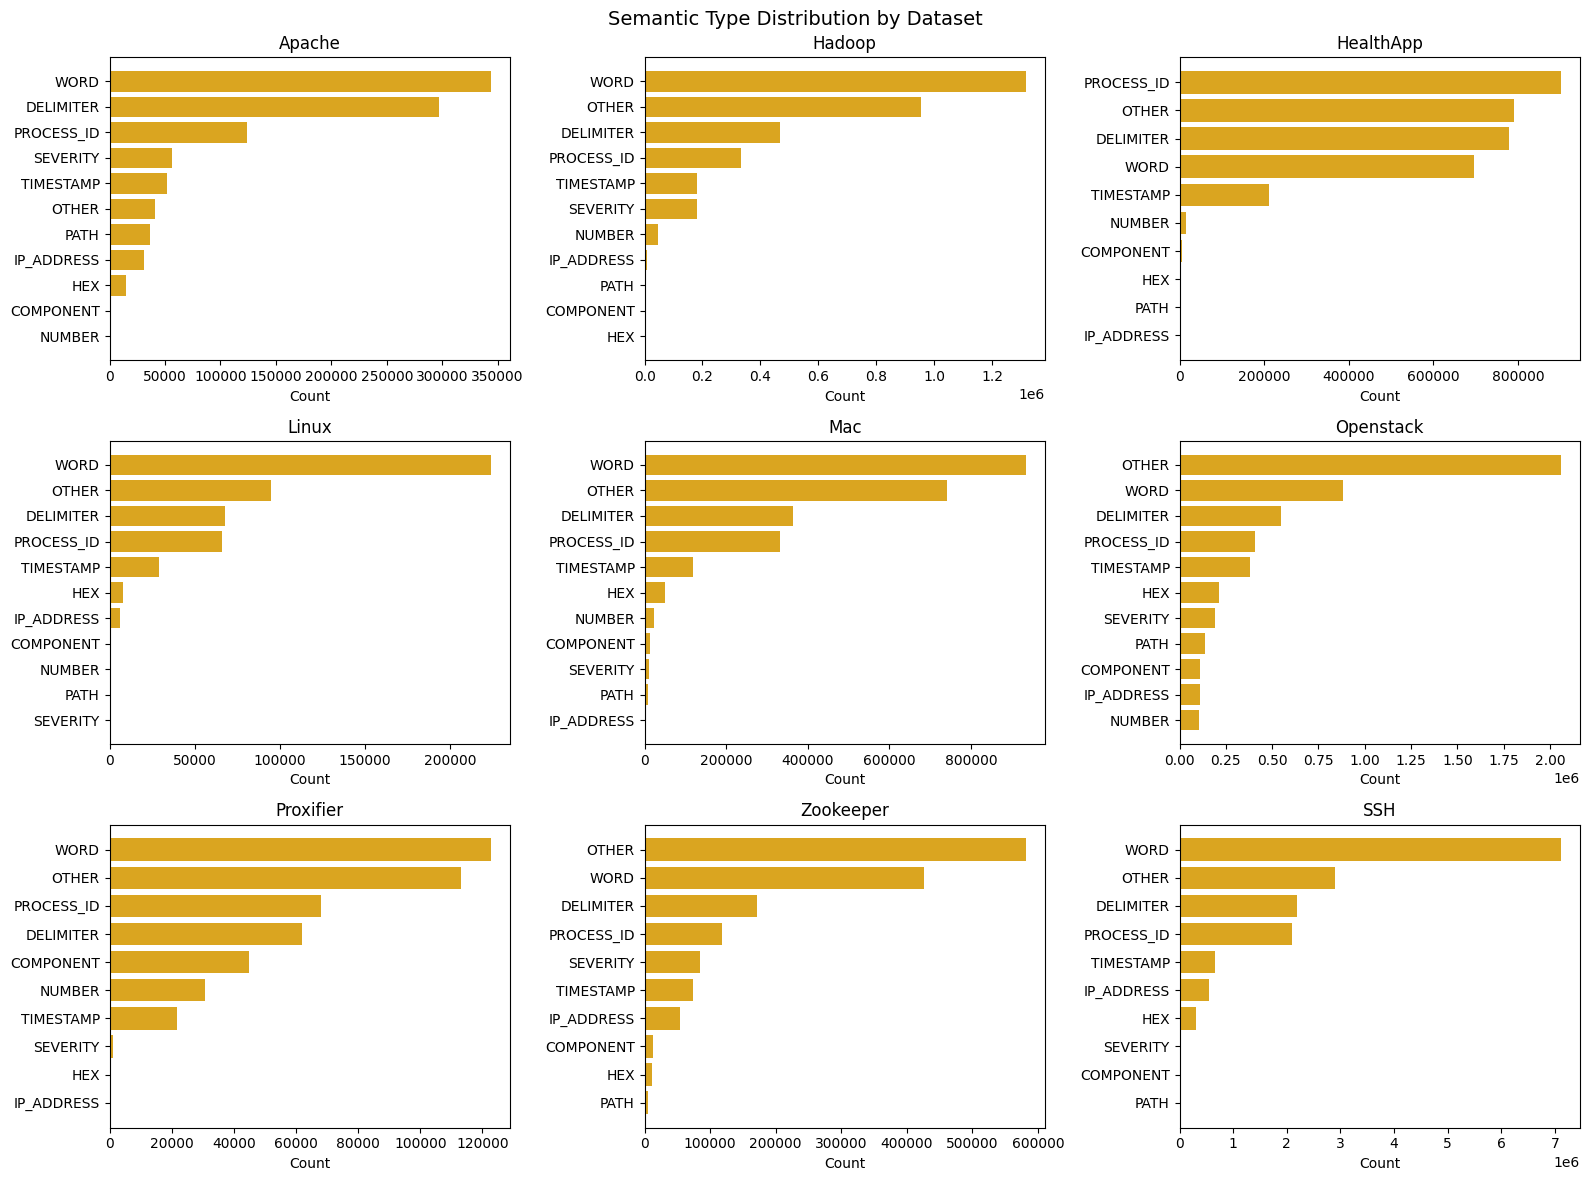

In [14]:
# Analyze semantic type distribution for all datasets and visualize results as a summary table and bar chart
type_distributions = {}

for name, classified_logs in classified_datasets.items():
    type_counts = Counter()
    for log in classified_logs:
        for token, token_type in log:
            type_counts[token_type] += 1
    type_distributions[name] = type_counts

# Create summary table
all_types = set()
for counts in type_distributions.values():
    all_types.update(counts.keys())
all_types = sorted(all_types)

print("Semantic Type Distribution by Dataset:\n")
header = f"{'Dataset':<12}" + "".join(f"{t:<12}" for t in all_types)
print(header)
print("-" * len(header))

# Build data for CSV
semantic_type_rows = []
for name in type_distributions:
    row = f"{name:<12}"
    row_data = {"Dataset": name}
    for t in all_types:
        count = type_distributions[name].get(t, 0)
        row += f"{count:<12,}"
        row_data[t] = count
    print(row)
    semantic_type_rows.append(row_data)

# Save to CSV
df_semantic = pd.DataFrame(semantic_type_rows)
df_semantic.to_csv(TABLES_DIR / "semantic_type_distribution.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/semantic_type_distribution.csv")

# Visualize as bar charts
num_datasets = len(type_distributions)
cols = 3
rows = (num_datasets + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for idx, name in enumerate(type_distributions.keys()):
    ax = axes[idx]
    counts = type_distributions[name]
    
    sorted_types = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    types = [t[0] for t in sorted_types]
    values = [t[1] for t in sorted_types]
    
    ax.barh(types, values, color="goldenrod")
    ax.set_xlabel("Count")
    ax.set_title(f"{name}")
    ax.invert_yaxis()

for idx in range(num_datasets, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Semantic Type Distribution by Dataset", fontsize=14)
plt.tight_layout()
plt.savefig('plots/semantic_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Show classification examples from each dataset
print("Classification Examples:\n")

for name, classified_logs in classified_datasets.items():
    if len(classified_logs) > 0:
        sample_log = classified_logs[0]
        original_log = datasets[name][0]
        
        print(f"=== {name} ===")
        print(f"Original: {original_log[:100]}..." if len(original_log) > 100 else f"Original: {original_log}")
        print("Classified tokens:")
        for token, token_type in sample_log[:10]:
            print(f"  {token_type:<12} : {token}")
        if len(sample_log) > 10:
            print(f"  ... and {len(sample_log) - 10} more tokens")
        print()

Classification Examples:

=== Apache ===
Original: [Thu Jun 09 06:07:04 2005] [notice] LDAP: Built with OpenLDAP LDAP SDK
Classified tokens:
  DELIMITER    : [
  WORD         : Thu
  WORD         : Jun
  PROCESS_ID   : 09
  TIMESTAMP    : 06:07:04
  PROCESS_ID   : 2005
  DELIMITER    : ]
  DELIMITER    : [
  SEVERITY     : notice
  DELIMITER    : ]
  ... and 7 more tokens

=== Hadoop ===
Original: 2015-10-17 21:48:16,337 INFO [main] org.apache.hadoop.metrics2.impl.MetricsConfig: loaded properties...
Classified tokens:
  OTHER        : 2015-10-17
  TIMESTAMP    : 21:48:16,337
  SEVERITY     : INFO
  DELIMITER    : [
  WORD         : main
  DELIMITER    : ]
  OTHER        : org.apache.hadoop.metrics2.impl.MetricsConfig
  OTHER        : :
  WORD         : loaded
  WORD         : properties
  ... and 2 more tokens

=== HealthApp ===
Original: 20171223-22:15:29:606|Step_LSC|30002312|onStandStepChanged 3579
Classified tokens:
  TIMESTAMP    : 20171223-22:15:29:606
  DELIMITER    : |
  WORD  

### Schema and template extraction

The algorithm looks at each token in a log and checks if it changes (like timestamps, IPs, numbers) or stays the same (like brackets, keywords).
Variable tokens are replaced with placeholders like `<TIMESTAMP>`, while constant tokens stay as it is, creating a template that groups similar logs together.

In [16]:
# Define semantic types are that variable (replaced with placeholders) and which are constant (kept in template)

VARIABLE_TYPES = {
    "TIMESTAMP",
    "IP_ADDRESS", 
    "PROCESS_ID",
    "NUMBER",
    "HEX",
    "BLOCK_ID",
    "PATH",
}

CONSTANT_TYPES = {
    "DELIMITER",
    "SEVERITY",
    "WORD",
    "COMPONENT",
    "OTHER",
}


def extract_template(classified_log):
    template_tokens = []
    
    for token, token_type in classified_log:
        if token_type in VARIABLE_TYPES:
            template_tokens.append(f"<*{token_type}*>")
        else:
            template_tokens.append(token)
    
    return tuple(template_tokens)


def template_to_string(template):
    return " ".join(template)

In [17]:
# Extract templates 
template_datasets = {}

print("Extracting templates for all datasets...\n")
print(f"{'Dataset':<12} {'Logs':>12} {'Unique Templates':>18}")
print("-" * 45)

for name, classified_logs in classified_datasets.items():
    start = time.time()
    
    templates = []
    for log in classified_logs:
        template = extract_template(log)
        templates.append(template)
    
    unique_templates = len(set(templates))
    elapsed = time.time() - start
    
    template_datasets[name] = templates
    
    print(f"{name:<12} {len(templates):>12,} {unique_templates:>18,}")

print("\nTemplate extraction complete.")

Extracting templates for all datasets...

Dataset              Logs   Unique Templates
---------------------------------------------
Apache             51,978                984
Hadoop            179,993             29,565
HealthApp         253,395             61,929
Linux              25,567              2,772
Mac               117,283             18,902
Openstack         189,386            128,699
Proxifier          21,320              2,117
Zookeeper          74,273                694
SSH               655,147              6,733

Template extraction complete.


Template Analysis:

Dataset        Total Logs    Templates  Logs/Template   Top Template
--------------------------------------------------------------------
Apache             51,978          984           52.8           3.4%
Hadoop            179,993       29,565            6.1           2.9%
HealthApp         253,395       61,929            4.1           7.0%
Linux              25,567        2,772            9.2          21.7%
Mac               117,283       18,902            6.2           3.0%
Openstack         189,386      128,699            1.5           2.1%
Proxifier          21,320        2,117           10.1          19.7%
Zookeeper          74,273          694          107.0          14.0%
SSH               655,147        6,733           97.3          11.2%

Saved to tables/template_analysis.csv


Top 5 Templates per Dataset:

=== Apache ===
  1. (1,748 logs, 3.4%) [ Sun Jan <*PROCESS_ID*> <*TIMESTAMP*> <*PROCESS_ID*> ] [ error ] [ cl...
  2. (1,677 logs, 3.2%) [ Sat Jan <*P

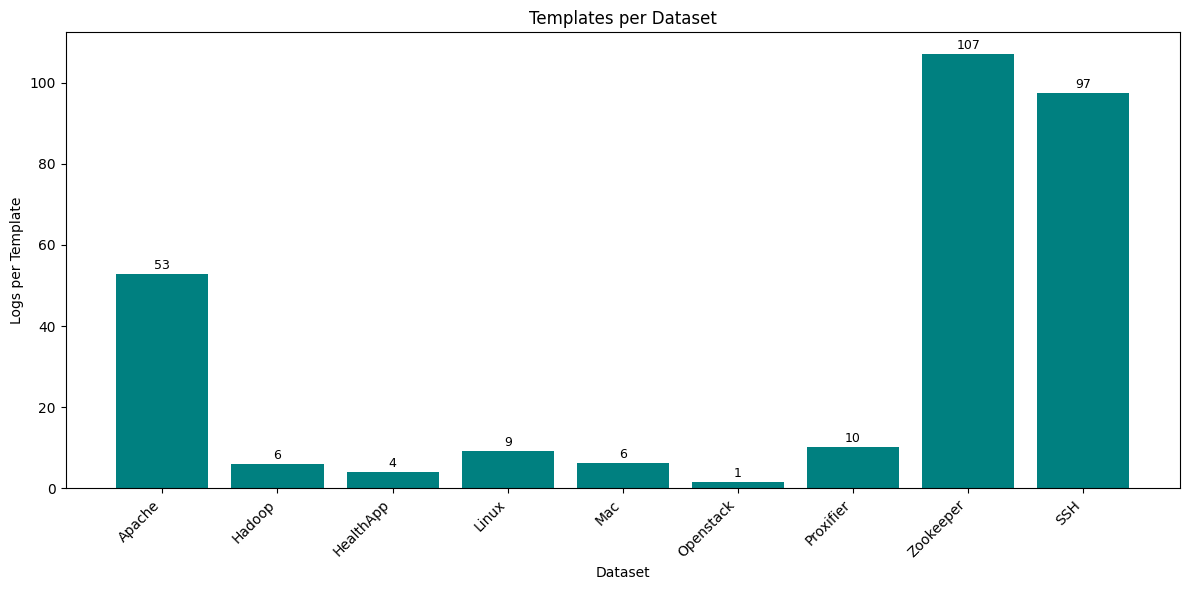

In [18]:
# Analyze template statistics
template_stats = {}

print("Template Analysis:\n")
print(f"{'Dataset':<12} {'Total Logs':>12} {'Templates':>12} {'Logs/Template':>14} {'Top Template':>14}")
print("-" * 68)

template_analysis_rows = []
for name, templates in template_datasets.items():
    template_counts = Counter(templates)
    total_logs = len(templates)
    num_templates = len(template_counts)
    
    # Compression ratio: how many logs share each template on average
    logs_per_template = total_logs / num_templates
    
    # Top template: what % of logs use the most common template
    top_template_count = template_counts.most_common(1)[0][1]
    top_template_pct = (top_template_count / total_logs) * 100
    
    template_stats[name] = {
        "total_logs": total_logs,
        "num_templates": num_templates,
        "template_counts": template_counts,
        "logs_per_template": logs_per_template,
        "top_template_pct": top_template_pct,
    }
    
    template_analysis_rows.append({
        "Dataset": name,
        "Total Logs": total_logs,
        "Templates": num_templates,
        "Logs/Template": round(logs_per_template, 1),
        "Top Template %": round(top_template_pct, 1)
    })
    
    print(f"{name:<12} {total_logs:>12,} {num_templates:>12,} {logs_per_template:>14.1f} {top_template_pct:>13.1f}%")

# Save template analysis to CSV
df_template_analysis = pd.DataFrame(template_analysis_rows)
df_template_analysis.to_csv(TABLES_DIR / "template_analysis.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/template_analysis.csv")

# Show top 5 templates for each dataset
print("\n\nTop 5 Templates per Dataset:\n")

top_templates_rows = []
for name, stats in template_stats.items():
    template_counts = stats["template_counts"]
    total_logs = stats["total_logs"]
    
    print(f"=== {name} ===")
    
    for rank, (template, count) in enumerate(template_counts.most_common(5), 1):
        pct = (count / total_logs) * 100
        template_str = template_to_string(template)
        if len(template_str) > 70:
            template_str = template_str[:70] + "..."
        print(f"  {rank}. ({count:,} logs, {pct:.1f}%) {template_str}")
        top_templates_rows.append({
            "Dataset": name,
            "Rank": rank,
            "Count": count,
            "Percentage": round(pct, 1),
            "Template": template_to_string(template)
        })
    
    print()

# Save top templates to CSV
df_top_templates = pd.DataFrame(top_templates_rows)
df_top_templates.to_csv(TABLES_DIR / "top_templates_per_dataset.csv", index=False)
print(f"Saved to {TABLES_DIR}/top_templates_per_dataset.csv")

# Logs per template bar chart 
fig, ax = plt.subplots(figsize=(12, 6))

dataset_names = list(template_stats.keys())
logs_per_template = [template_stats[name]["logs_per_template"] for name in dataset_names]

bars = ax.bar(dataset_names, logs_per_template, color="teal")

ax.set_xlabel("Dataset")
ax.set_ylabel("Logs per Template")
ax.set_title("Templates per Dataset")
ax.set_xticks(range(len(dataset_names)))
ax.set_xticklabels(dataset_names, rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig('plots/logs_per_template.png', dpi=300, bbox_inches='tight')

plt.show()

### Compression
Compress logs with schema-based encoding.

Dictionary encoding for templates.

In [19]:
# Template dictionaries for compression (Maps each unique template to an integer ID)

template_dicts = {}

for name, stats in template_stats.items():
    template_counts = stats["template_counts"]
    
    # Sort by frequency
    sorted_templates = [t for t, _ in template_counts.most_common()]
    
    template_to_id = {template: idx for idx, template in enumerate(sorted_templates)}
    id_to_template = {idx: template for template, idx in template_to_id.items()}
    
    template_dicts[name] = {
        "template_to_id": template_to_id,
        "id_to_template": id_to_template,
    }

print(f"Template dictionaries created for {len(template_dicts)} datasets.")

Template dictionaries created for 9 datasets.


In [20]:
# Constants and Configuration Mapping

# Severity list
SEVERITY_LIST = ["INFO", "WARN", "WARNING", "ERROR", "DEBUG", "FATAL", "TRACE", "NOTICE", "CRITICAL", "SEVERE"]
SEVERITY_TO_ID = {s: i for i, s in enumerate(SEVERITY_LIST)}
SEVERITY_FROM_ID = {i: s for i, s in enumerate(SEVERITY_LIST)}

# Type codes - SEMANTIC ENCODING
TYPE_TS = 0     # Timestamp (delta-encoded seconds)
TYPE_SEV = 1    # Severity (encoded as integer ID)
TYPE_IP = 2     # IP Address (encoded as 32-bit integer)
TYPE_PORT = 3   # Port number (16-bit integer)
TYPE_INT = 4    # Generic integer (process ID, numbers)
TYPE_HEX = 5    # Hex value (stored as integer)
TYPE_PATH = 6   # File Path (dictionary encoded - strings)
TYPE_RAW = 7    # Unknown - store as raw string


In [21]:
# Timestamp conversion function

def timestamp_to_seconds(ts_string):
    formats = [
        "%Y-%m-%d %H:%M:%S",
        "%Y-%m-%dT%H:%M:%S",
        "%Y-%m-%d %H:%M:%S,%f",
        "%H:%M:%S",
        "%H:%M:%S,%f",
    ]
    
    for fmt in formats:
        try:
            dt = datetime.strptime(ts_string, fmt)
            return int(dt.timestamp()) if dt.year > 1970 else int(dt.hour * 3600 + dt.minute * 60 + dt.second)
        except:
            pass
    
    # In case of numeric timestamp (like 081109 for HHMMSS)
    if ts_string.isdigit() and len(ts_string) == 6:
        try:
            h, m, s = int(ts_string[:2]), int(ts_string[2:4]), int(ts_string[4:6])
            return h * 3600 + m * 60 + s
        except:
            pass
    
    return None

In [22]:
# Compression and Decompression Functions For Templates 
# Instead of storing full template, we build a token dictionary and store templates as lists of token IDs.

def compress_templates(id_to_template):
    # Build token dictionary from all templates
    token_to_id = {}
    for template in id_to_template.values():
        for token in template:
            if token not in token_to_id:
                token_to_id[token] = len(token_to_id)
    
    # Store templates as lists of token IDs
    compressed_templates = {}
    for tid, template in id_to_template.items():
        compressed_templates[tid] = [token_to_id[t] for t in template]
    
    return {
        "tokens": {v: k for k, v in token_to_id.items()},  # id -> token
        "templates": compressed_templates,  # template_id -> [token_ids]
    }

 
def decompress_templates(compressed_template_data): 
    tokens = compressed_template_data["tokens"]
    templates = compressed_template_data["templates"]
    
    # Handle both integer and string keys in tokens dict
    tokens_normalized = {}
    for k, v in tokens.items():
        tokens_normalized[int(k) if isinstance(k, (str, int)) else k] = v
    
    id_to_template = {}
    for tid, token_ids in templates.items():
        id_to_template[int(tid)] = [tokens_normalized[int(tok_id)] for tok_id in token_ids]
    
    return id_to_template


In [23]:
# Compress logs separators Function
def compress_separators(all_separators):

    # Build dictionary of unique separator strings
    sep_to_id = {"": 0, " ": 1} # common separators
    next_id = 2
    
    compressed_seps = []
    for log_seps in all_separators:
        log_compressed = []
        for sep in log_seps:
            if sep not in sep_to_id:
                sep_to_id[sep] = next_id
                next_id += 1
            log_compressed.append(sep_to_id[sep])
        compressed_seps.append(log_compressed)
    
    return {
        "sep_dict": {v: k for k, v in sep_to_id.items()},
        "separators": compressed_seps,
    }

In [24]:
# SEMANTIC ENCODING FUNCTIONS
# Convert tokens to native typed values

def ip_to_int(ip_string):# Convert IPv4 address to 32-bit integer example '192.168.1.5' -> 3232235781 
    # Handle IP:port format
    if ':' in ip_string:
        ip_part = ip_string.split(':')[0]
    else:
        ip_part = ip_string
    
    try:
        parts = ip_part.split('.')
        if len(parts) == 4:
            return (int(parts[0]) << 24) + (int(parts[1]) << 16) + (int(parts[2]) << 8) + int(parts[3])
    except:
        pass
    return None

def int_to_ip(ip_int): #Convert 32-bit integer back to IPv4 string. example 3232235781 -> '192.168.1.5' 
    return f"{(ip_int >> 24) & 0xFF}.{(ip_int >> 16) & 0xFF}.{(ip_int >> 8) & 0xFF}.{ip_int & 0xFF}"

def hex_to_int(hex_string): # Convert hex string to integer. example '0x1a2b' -> 6699, 'deadbeef' -> 3735928559
    # Limit to 64-bit integers (msgpack max) - longer hex strings stay as strings
    try:
        if hex_string.startswith('0x') or hex_string.startswith('0X'):
            val = int(hex_string, 16)
        else:
            val = int(hex_string, 16)
        # Check if value fits in 64-bit signed integer range for msgpack
        if val > 0x7FFFFFFFFFFFFFFF:  # Max signed 64-bit
            return None  # Too large, will fall back to string storage
        return val
    except:
        return None

def extract_port(token): # Extract port from IP:port format. example '192.168.1.5:22' -> 22
    if ':' in token:
        try:
            return int(token.split(':')[1])
        except:
            pass
    return None


def encode_token(token, token_type, path_dict, raw_dict, ts_tracker):
    #SEMANTIC ENCODER: Convert tokens to native typed values.
    # TIMESTAMP: delta-encoded seconds (numeric)
    # IP_ADDRESS: 32-bit integer
    # PROCESS_ID/NUMBER: native integer
    # HEX: native integer
    # PATH: dictionary (strings)
 
    if token_type == "TIMESTAMP":
        ts = timestamp_to_seconds(token)
        if ts is not None:
            ts_tracker["values"].append(ts)
            ts_tracker["positions"].append(ts_tracker["current_position"])
            # Store: [TYPE, delta_value, original_string_for_reconstruction]
            return [TYPE_TS, ts, token] 
        else:
            return [TYPE_RAW, token]
    
    elif token_type == "IP_ADDRESS":
        # SEMANTIC: Convert IP to 32-bit integer
        ip_int = ip_to_int(token)
        port = extract_port(token)
        if ip_int is not None:
            if port is not None:
                # IP with port: store both as integers
                return [TYPE_IP, ip_int, port]
            else:
                return [TYPE_IP, ip_int]
        else:
            return [TYPE_RAW, token]
    
    elif token_type == "PATH":
        # dictionary encoding for paths (strings)
        if token not in path_dict:
            path_dict[token] = len(path_dict)
        return [TYPE_PATH, path_dict[token]]
    
    elif token_type == "PROCESS_ID" or token_type == "NUMBER":
        # SEMANTIC: Store as native integer (must fit in 64-bit for msgpack)
        try:
            num = int(token)
            if num > 0x7FFFFFFFFFFFFFFF or num < -0x8000000000000000:
                return [TYPE_RAW, token]  # Too large for msgpack
            return [TYPE_INT, num]
        except:
            # If can't parse as int, fall back to raw
            return [TYPE_RAW, token]
    
    elif token_type == "HEX":
        # SEMANTIC: Convert hex to integer, but PRESERVE original format for reconstruction
        hex_int = hex_to_int(token)
        if hex_int is not None:
            # Store: [TYPE_HEX, integer_value, original_string]
            return [TYPE_HEX, hex_int, token]
        else:
            return [TYPE_RAW, token]
    
    elif token_type == "BLOCK_ID":
        # Block IDs like blk_-1234567890 - keep as string for now
        if token not in raw_dict:
            raw_dict[token] = len(raw_dict)
        return [TYPE_RAW, raw_dict[token], token]
    
    else:
        # Constant token - not encoded (handled by template)
        return None


def encode_log_values(classified_log, path_dict, raw_dict, ts_tracker):
    # Encode all variable tokens in a classified log.
    log_values = []

    for token, token_type in classified_log:
        ts_tracker["current_position"] = (ts_tracker["log_idx"], len(log_values))
        
        encoded = encode_token(token, token_type, path_dict, raw_dict, ts_tracker)
        if encoded is not None:
            log_values.append(encoded)
    
    return log_values


In [25]:
# Delta Encoding Function (for timestamps)

def delta_encode_timestamps(all_values, ts_tracker):

    raw_timestamps = ts_tracker["values"]
    positions = ts_tracker["positions"]
    
    if not raw_timestamps:
        return None
    
    baseline = raw_timestamps[0]
    
    # Calculate deltas
    delta_timestamps = [0]
    for i in range(1, len(raw_timestamps)):
        delta_timestamps.append(raw_timestamps[i] - raw_timestamps[i-1])
    
    # Update values in place with deltas
    for i, (log_idx, value_idx) in enumerate(positions):
        all_values[log_idx][value_idx][1] = delta_timestamps[i]
    
    return baseline

In [26]:
# Main Compression Function - SEMANTIC ENCODING
# Encodes semantic types as native values (integers) instead of string dictionary lookups

def compress_dataset(name, classified_logs, templates, template_dict, separators):
    template_to_id = template_dict["template_to_id"]
    
    # Dictionaries only for string-based types (paths, raw fallbacks)
    # NOTE: IPs and numbers are now stored as native integers, no dictionary needed
    path_dict = {}
    raw_dict = {}
    
    # Timestamp tracking for delta encoding
    ts_tracker = {
        "values": [],
        "positions": [],
        "log_idx": 0,
        "current_position": None,
    }
    
    # Encode each log
    template_ids = []
    all_values = []
    
    for log_idx, (classified_log, template) in enumerate(zip(classified_logs, templates)):
        ts_tracker["log_idx"] = log_idx
        template_ids.append(template_to_id[template])
        log_values = encode_log_values(classified_log, path_dict, raw_dict, ts_tracker)
        all_values.append(log_values)
    
    # Apply delta encoding to timestamps
    baseline = delta_encode_timestamps(all_values, ts_tracker)
    
    # Build reverse dictionaries for decompression (only for string types)
    id_to_path = {v: k for k, v in path_dict.items()}
    id_to_raw = {v: k for k, v in raw_dict.items()}
    
    # Compress template dictionary and separators
    compressed_templates = compress_templates(template_dict["id_to_template"])
    compressed_seps = compress_separators(separators)
    
    return {
        "template_ids": template_ids,
        "values": all_values,
        "timestamp_baseline": baseline,
        "templates": compressed_templates,
        "id_to_path": id_to_path,
        "id_to_raw": id_to_raw,
        "separators": compressed_seps,
    }


In [27]:
# Function raw log size
def get_original_size(logs):
    text = "\n".join(logs)
    return len(text.encode("utf-8"))


# Gzip compression function
def compress_with_gzip(logs): 
    text = "\n".join(logs)
    data = text.encode("utf-8")
    start = time.time()
    compressed = gzip.compress(data, compresslevel=9)
    elapsed = time.time() - start
    return len(compressed), elapsed



In [28]:
# Bzip2 compression function
def compress_with_bzip2(logs): 
    text = "\n".join(logs)
    data = text.encode("utf-8")
    start = time.time()
    compressed = bz2.compress(data, compresslevel=9)
    elapsed = time.time() - start
    return len(compressed), elapsed

In [29]:
# Lzma compression function
def compress_with_lzma(logs): 
    text = "\n".join(logs)
    data = text.encode("utf-8")
    start = time.time()
    compressed = lzma.compress(data, preset=9)
    elapsed = time.time() - start
    return len(compressed), elapsed


In [30]:

# Zstd compression function to raw logs without schema extraction
def compress_with_zstd_raw(logs):
    text = "\n".join(logs)
    data = text.encode("utf-8")
    cctx = zstd.ZstdCompressor(level=9) 
    start = time.time()
    compressed = cctx.compress(data)
    elapsed = time.time() - start
    return len(compressed), elapsed

In [31]:
def prepare_for_msgpack(data):
    #Convert data to msgpack-compatible format (tuples to lists, large ints to strings). 
    MAX_INT = 0x7FFFFFFFFFFFFFFF  # Max 64-bit signed integer
    MIN_INT = -0x8000000000000000
    
    if isinstance(data, dict):
        # Convert tuple keys to strings for id_to_template
        result = {}
        for k, v in data.items():
            if isinstance(k, tuple):
                result[str(k)] = prepare_for_msgpack(v)
            else:
                result[k] = prepare_for_msgpack(v)
        return result
    elif isinstance(data, (list, tuple)):
        return [prepare_for_msgpack(item) for item in data]
    elif isinstance(data, int):
        # Handle integers that exceed msgpack's 64-bit range
        if data > MAX_INT or data < MIN_INT:
            return str(data)  # Convert to string if too large
        return data
    else:
        return data

In [32]:
# Logpress compression function
def compress_with_logpress(compressed_data):
    #Compress structured data with msgpack + zstd.
    start = time.time()
    # Convert to msgpack-compatible format
    msgpack_data = prepare_for_msgpack(compressed_data)
    packed = msgpack.packb(msgpack_data, use_bin_type=True)
    cctx = zstd.ZstdCompressor(level=9) 
    compressed = cctx.compress(packed)
    elapsed = time.time() - start
    return compressed, len(compressed), elapsed

In [33]:
# LogPress Save Compressed logs Function
def save_logpress_compressed(datasets, classified_datasets, template_datasets, 
                             template_dicts, separator_datasets, output_dir="compressed"):
    OUTPUT_DIR = Path(output_dir)
    OUTPUT_DIR.mkdir(exist_ok=True)
    
    summary = {}
    for name in datasets.keys():
        compressed_data = compress_dataset(
            name, classified_datasets[name], template_datasets[name],
            template_dicts[name], separator_datasets[name]
        )
        compressed_bytes, size_bytes, elapsed = compress_with_logpress(compressed_data)
        
        output_path = OUTPUT_DIR / f"{name}.logpress"
        with open(output_path, "wb") as f:
            f.write(compressed_bytes)
        
        summary[name] = {
            "path": str(output_path),
            "size_kb": size_bytes / 1024,
            "size_bytes": size_bytes,
            "compression_time": elapsed
        }
    
    print(f"Saved {len(summary)} files to {OUTPUT_DIR}/")
    return summary


In [34]:
# Compress all datasets
compression_results = {}
OUTPUT_DIR = Path("compressed")
OUTPUT_DIR.mkdir(exist_ok=True)


for name in datasets.keys():
    logs = datasets[name]
    
    original_size = get_original_size(logs)
    gzip_size, gzip_time = compress_with_gzip(logs)
    bzip2_size, bzip2_time = compress_with_bzip2(logs)
    lzma_size, lzma_time = compress_with_lzma(logs)
    zstd_raw_size, zstd_raw_time = compress_with_zstd_raw(logs)
    
    # LogPress: prepare structured data (not timed - already preprocessed)
    compressed_data = compress_dataset(
        name,
        classified_datasets[name],
        template_datasets[name],
        template_dicts[name],
        separator_datasets[name]
    )
    # Only time the actual compression step (msgpack + zstd)
    _, logpress_size, logpress_time = compress_with_logpress(compressed_data)
    
    compression_results[name] = {
        "original": original_size,
        "gzip": gzip_size,
        "bzip2": bzip2_size,
        "lzma": lzma_size,
        "zstd_raw": zstd_raw_size,
        "logpress": logpress_size,
        "gzip_time": gzip_time,
        "bzip2_time": bzip2_time,
        "lzma_time": lzma_time,
        "zstd_raw_time": zstd_raw_time,
        "logpress_time": logpress_time,
    }
    

summary = save_logpress_compressed(datasets,classified_datasets,template_datasets,template_dicts,separator_datasets,output_dir="compressed")

print(f"LogPress Compression Summary:\nTotal files saved: {len(summary)} folder")
print(f"  Total compressed size: {sum(info['size_kb'] for info in summary.values()):.1f} KB")
print(f"  Average compression time: {sum(info['compression_time'] for info in summary.values()) / len(summary):.2f}s per dataset")


Saved 9 files to compressed/
LogPress Compression Summary:
Total files saved: 9 folder
  Total compressed size: 13734.2 KB
  Average compression time: 3.61s per dataset


In [35]:
# Calculate compression ratios
print("\n\nCompression Ratios (Original / Compressed):\n")
print(f"{'Dataset':<12} {'Gzip':>10} {'Bzip2':>10} {'LZMA':>10} {'Zstd':>10} {'LogPress':>10}")
print("-" * 64)

compression_ratio_rows = []
for name, results in compression_results.items():
    orig = results["original"]
    row = {
        "Dataset": name,
        "Gzip": round(orig/results['gzip'], 1),
        "Bzip2": round(orig/results['bzip2'], 1),
        "LZMA": round(orig/results['lzma'], 1),
        "Zstd": round(orig/results['zstd_raw'], 1),
        "LogPress": round(orig/results['logpress'], 1)
    }
    compression_ratio_rows.append(row)
    print(f"{name:<12} {orig/results['gzip']:>9.1f}x {orig/results['bzip2']:>9.1f}x {orig/results['lzma']:>9.1f}x {orig/results['zstd_raw']:>9.1f}x {orig/results['logpress']:>9.1f}x")

# Total compression ratios
total = {k: sum(r[k] for r in compression_results.values()) for k in ["original", "gzip", "bzip2", "lzma", "zstd_raw", "logpress"]}
print("-" * 64)
print(f"{'TOTAL':<12} {total['original']/total['gzip']:>9.1f}x {total['original']/total['bzip2']:>9.1f}x {total['original']/total['lzma']:>9.1f}x {total['original']/total['zstd_raw']:>9.1f}x {total['original']/total['logpress']:>9.1f}x")

compression_ratio_rows.append({
    "Dataset": "TOTAL",
    "Gzip": round(total['original']/total['gzip'], 1),
    "Bzip2": round(total['original']/total['bzip2'], 1),
    "LZMA": round(total['original']/total['lzma'], 1),
    "Zstd": round(total['original']/total['zstd_raw'], 1),
    "LogPress": round(total['original']/total['logpress'], 1)
})

# Save to CSV
df_compression_ratios = pd.DataFrame(compression_ratio_rows)
df_compression_ratios.to_csv(TABLES_DIR / "compression_ratios.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/compression_ratios.csv")



Compression Ratios (Original / Compressed):

Dataset            Gzip      Bzip2       LZMA       Zstd   LogPress
----------------------------------------------------------------
Apache            21.2x      29.2x      28.5x      24.6x      20.4x
Hadoop            14.7x      22.5x      25.7x      23.1x      22.3x
HealthApp         10.8x      13.7x      15.6x      13.0x      10.1x
Linux             11.2x      14.7x      20.0x      16.6x      11.6x
Mac               11.7x      18.0x      24.3x      22.3x      17.5x
Openstack         12.2x      15.3x      15.7x      13.9x      11.9x
Proxifier         15.7x      23.6x      21.0x      17.9x      14.1x
Zookeeper         25.9x      36.1x      29.8x      32.2x      32.1x
SSH               16.7x      22.6x      20.7x      19.9x      19.7x
----------------------------------------------------------------
TOTAL             14.1x      19.0x      19.6x      17.8x      15.7x

Saved to tables/compression_ratios.csv


In [36]:
# Compression time
print("\n\nCompression Time (seconds):\n")
print(f"{'Dataset':<12} {'Gzip':>10} {'Bzip2':>10} {'LZMA':>10} {'Zstd':>10} {'LogPress':>10}")
print("-" * 64)

compression_time_rows = []
for name, results in compression_results.items():
    row = {
        "Dataset": name,
        "Gzip": round(results['gzip_time'], 2),
        "Bzip2": round(results['bzip2_time'], 2),
        "LZMA": round(results['lzma_time'], 2),
        "Zstd": round(results['zstd_raw_time'], 2),
        "LogPress": round(results['logpress_time'], 2)
    }
    compression_time_rows.append(row)
    print(f"{name:<12} {results['gzip_time']:>9.2f}s {results['bzip2_time']:>9.2f}s {results['lzma_time']:>9.2f}s {results['zstd_raw_time']:>9.2f}s {results['logpress_time']:>9.2f}s")

total_times = {
    "gzip": sum(r["gzip_time"] for r in compression_results.values()),
    "bzip2": sum(r["bzip2_time"] for r in compression_results.values()),
    "lzma": sum(r["lzma_time"] for r in compression_results.values()),
    "zstd_raw": sum(r["zstd_raw_time"] for r in compression_results.values()),
    "logpress": sum(r["logpress_time"] for r in compression_results.values()),
}
print("-" * 64)
print(f"{'TOTAL':<12} {total_times['gzip']:>9.2f}s {total_times['bzip2']:>9.2f}s {total_times['lzma']:>9.2f}s {total_times['zstd_raw']:>9.2f}s {total_times['logpress']:>9.2f}s")

compression_time_rows.append({
    "Dataset": "TOTAL",
    "Gzip": round(total_times['gzip'], 2),
    "Bzip2": round(total_times['bzip2'], 2),
    "LZMA": round(total_times['lzma'], 2),
    "Zstd": round(total_times['zstd_raw'], 2),
    "LogPress": round(total_times['logpress'], 2)
})

# Save to CSV
df_compression_times = pd.DataFrame(compression_time_rows)
df_compression_times.to_csv(TABLES_DIR / "compression_times.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/compression_times.csv")



Compression Time (seconds):

Dataset            Gzip      Bzip2       LZMA       Zstd   LogPress
----------------------------------------------------------------
Apache            0.13s      0.65s      0.85s      0.03s      0.47s
Hadoop            0.39s      3.11s      4.66s      0.20s      3.63s
HealthApp         0.62s      1.58s      6.96s      0.23s      4.13s
Linux             0.06s      0.19s      0.49s      0.02s      0.22s
Mac               0.19s      1.38s      2.25s      0.11s      3.22s
Openstack         0.53s      5.77s     11.43s      0.40s      5.50s
Proxifier         0.04s      0.25s      0.30s      0.02s      0.22s
Zookeeper         0.20s      0.98s      1.29s      0.06s      0.59s
SSH               1.59s      6.25s     16.97s      0.50s     12.02s
----------------------------------------------------------------
TOTAL             3.74s     20.14s     45.21s      1.57s     30.00s

Saved to tables/compression_times.csv


In [37]:
# Plots Visualization of compression results

dataset_names = list(compression_results.keys())
methods = ["gzip", "bzip2", "lzma", "zstd_raw", "logpress"]
colors = ["#4A4A4A", "#1ABC9C", "#E67E22", "#3498DB", "#95A5A6"]
method_labels = ["Gzip", "Bzip2", "LZMA", "Zstd (raw)", "LogPress"]

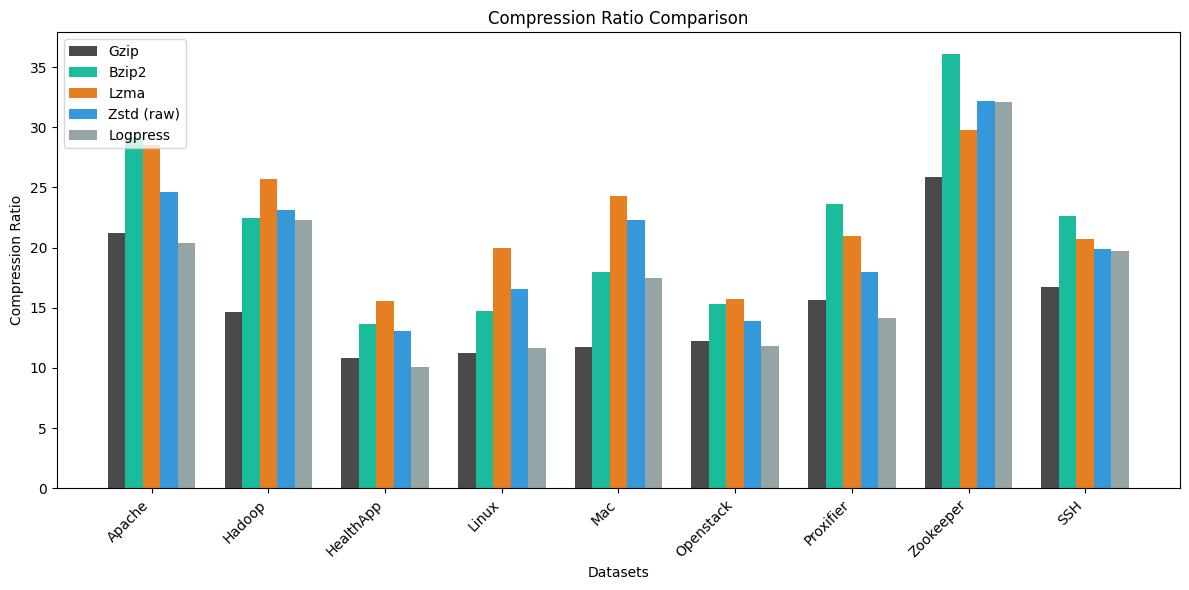

In [38]:
# Chart 1: Compression Ratios comparison

fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(dataset_names))
width = 0.15

for i, (method, color) in enumerate(zip(methods, colors)):
    ratios = [compression_results[name]["original"] / compression_results[name][method] for name in dataset_names]
    offset = (i - 2) * width
    label = "Zstd (raw)" if method == "zstd_raw" else method.capitalize()
    ax1.bar(x + offset, ratios, width, label=label, color=color)

ax1.set_xlabel("Datasets")
ax1.set_ylabel("Compression Ratio")
ax1.set_title("Compression Ratio Comparison")
ax1.set_xticks(x)
ax1.set_xticklabels(dataset_names, rotation=45, ha="right")
ax1.legend(loc="upper left")
plt.tight_layout()
plt.savefig('plots/compression_ratio_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

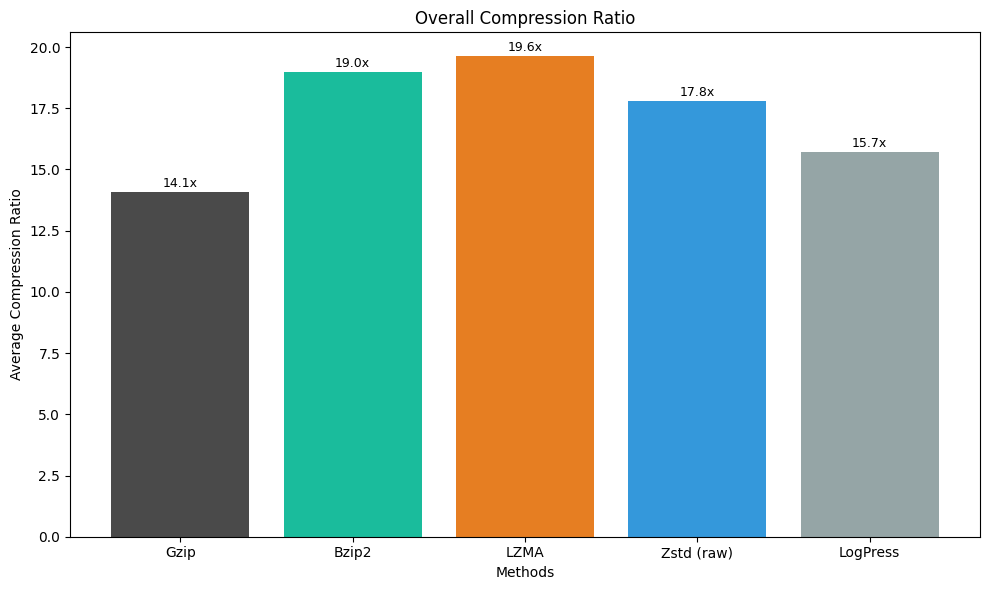

In [39]:
# Chart 2: Average compression ratio per method
fig, ax2 = plt.subplots(figsize=(10, 6))
avg_ratios = []
for method in methods:
    total_orig = sum(compression_results[name]["original"] for name in dataset_names)
    total_comp = sum(compression_results[name][method] for name in dataset_names)
    avg_ratios.append(total_orig / total_comp)

bars = ax2.bar(method_labels, avg_ratios, color=colors)
ax2.set_xlabel("Methods")
ax2.set_ylabel("Average Compression Ratio")
ax2.set_title("Overall Compression Ratio")

for bar, ratio in zip(bars, avg_ratios):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f"{ratio:.1f}x", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig('plots/compression_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

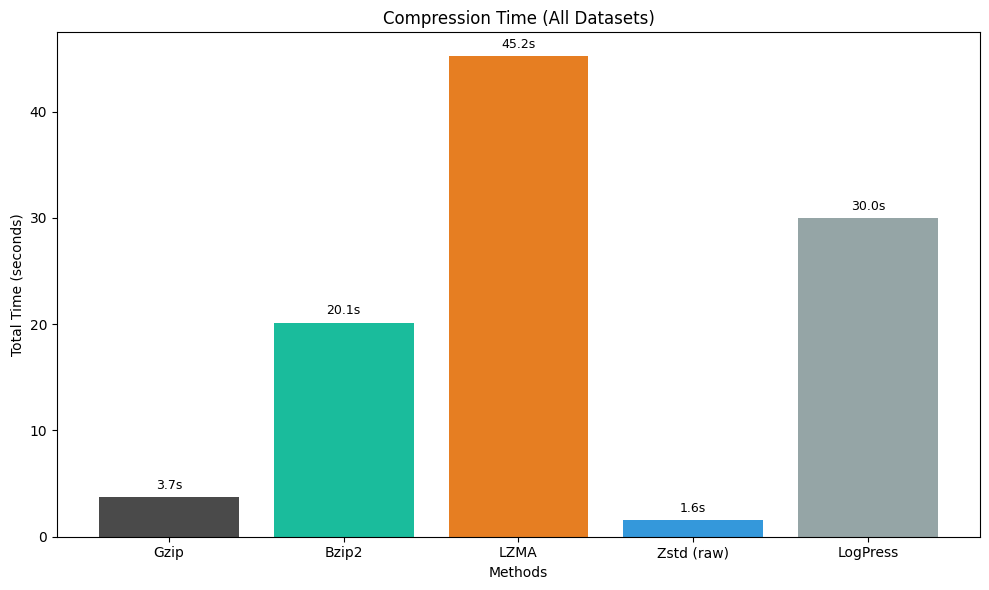

In [40]:
# Chart 3: Total compression time per method
fig, ax3 = plt.subplots(figsize=(10, 6))
total_times = [
    sum(compression_results[name]["gzip_time"] for name in dataset_names),
    sum(compression_results[name]["bzip2_time"] for name in dataset_names),
    sum(compression_results[name]["lzma_time"] for name in dataset_names),
    sum(compression_results[name]["zstd_raw_time"] for name in dataset_names),
    sum(compression_results[name]["logpress_time"] for name in dataset_names),
]

bars = ax3.bar(method_labels, total_times, color=colors)
ax3.set_xlabel("Methods")
ax3.set_ylabel("Total Time (seconds)")
ax3.set_title("Compression Time (All Datasets)")

for bar, t in zip(bars, total_times):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f"{t:.1f}s", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig('plots/compression_time.png', dpi=300, bbox_inches='tight')
plt.show()

In [41]:
# Summary 
print("Compression Performance Summary\n")
print(f"  {'-'*70}")
print(f"  {'Method':<15} {'Ratio':>10} {'Time':>10} {'Speed':>12}")
print(f"  {'-'*70}")

speed_efficiency = []
performance_summary_rows = []
for i, method in enumerate(method_labels):
    # Speed efficiency: compression ratio per second
    efficiency = avg_ratios[i] / total_times[i] if total_times[i] > 0 else 0
    speed_efficiency.append(efficiency)
    performance_summary_rows.append({
        "Method": method,
        "Ratio": round(avg_ratios[i], 1),
        "Time (s)": round(total_times[i], 1),
        "Speed (x/s)": round(efficiency, 3)
    })
    print(f"  {method:<15} {avg_ratios[i]:>9.1f}x {total_times[i]:>9.1f}s {efficiency:>11.3f}x/s")

print(f"  {'-'*70}")

# Best performers by category
best_ratio_idx = avg_ratios.index(max(avg_ratios))
best_speed_idx = total_times.index(min(total_times))
best_efficiency_idx = speed_efficiency.index(max(speed_efficiency))

print(f"  Best Compression Ratio:    {method_labels[best_ratio_idx]} ({avg_ratios[best_ratio_idx]:.1f}x)")
print(f"  Fastest Compression:       {method_labels[best_speed_idx]} ({total_times[best_speed_idx]:.1f}s)")
print(f"  Best Efficiency (ratio/s): {method_labels[best_efficiency_idx]} ({speed_efficiency[best_efficiency_idx]:.3f}x/s)")

# LogPress  analysis
print(f"  {'-'*70}")
logpress_idx = 4
best_baseline_ratio = max(avg_ratios[:4])
best_baseline_idx = avg_ratios[:4].index(best_baseline_ratio)

ratio_improvement = ((avg_ratios[logpress_idx] - best_baseline_ratio) / best_baseline_ratio) * 100
time_comparison = ((total_times[logpress_idx] - total_times[best_baseline_idx]) / total_times[best_baseline_idx]) * 100

print(f"LogPress Analysis vs Best Baseline ({method_labels[best_baseline_idx]}):")
print(f"        Ratio difference:  {ratio_improvement:+.1f}% {'✓' if ratio_improvement > 0 else '✗'}")
print(f"        Time difference:   {time_comparison:+.1f}% {'✓' if time_comparison < 0 else '✗'}")
print(f"        Efficiency:        {speed_efficiency[logpress_idx]:.3f}x/s")

# Save performance summary to CSV
df_performance = pd.DataFrame(performance_summary_rows)
df_performance.to_csv(TABLES_DIR / "compression_performance_summary.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/compression_performance_summary.csv")

Compression Performance Summary

  ----------------------------------------------------------------------
  Method               Ratio       Time        Speed
  ----------------------------------------------------------------------
  Gzip                 14.1x       3.7s       3.763x/s
  Bzip2                19.0x      20.1s       0.942x/s
  LZMA                 19.6x      45.2s       0.434x/s
  Zstd (raw)           17.8x       1.6s      11.357x/s
  LogPress             15.7x      30.0s       0.524x/s
  ----------------------------------------------------------------------
  Best Compression Ratio:    LZMA (19.6x)
  Fastest Compression:       Zstd (raw) (1.6s)
  Best Efficiency (ratio/s): Zstd (raw) (11.357x/s)
  ----------------------------------------------------------------------
LogPress Analysis vs Best Baseline (LZMA):
        Ratio difference:  -20.0% ✗
        Time difference:   -33.7% ✓
        Efficiency:        0.524x/s

Saved to tables/compression_performance_summary.csv


### To prove that our Compression works correctly, we verify that by simply Decompressing our .logpress files and reconstruct logs to verify our loseless compression.

In [42]:
# Load and Decompress .logpress files Function
def decompress_logpress(filepath):
    with open(filepath, "rb") as f:
        compressed = f.read()
    
    dctx = zstd.ZstdDecompressor()
    packed = dctx.decompress(compressed) 
    data = msgpack.unpackb(packed, raw=False, strict_map_key=False)
    return data

In [43]:
# Decompress separators function
def decompress_separators(compressed_sep_data): 
    sep_dict = {int(k): v for k, v in compressed_sep_data["sep_dict"].items()}
    compressed_seps = compressed_sep_data["separators"]
    
    all_separators = []
    for log_seps in compressed_seps:
        all_separators.append([sep_dict[sid] for sid in log_seps])
    
    return all_separators

In [44]:
# Decode value function - SEMANTIC DECODING
# Converts native typed values back to original string representation

def decode_value(value_tuple, id_to_path, id_to_raw):
    # SEMANTIC DECODER: Convert native typed values back to strings for reconstruction.
    #- TYPE_TS: Use stored original string
    #- TYPE_IP: Convert 32-bit integer back to dotted notation
    #- TYPE_INT: Convert integer to string
    #- TYPE_HEX: Convert integer back to hex string (with 0x prefix)
    #- TYPE_PATH: Dictionary lookup
    #- TYPE_RAW: Direct string or dictionary lookup
    val_type = value_tuple[0]
    
    if val_type == TYPE_TS:
        # Timestamp: original string stored at index 2
        return value_tuple[2]
    
    elif val_type == TYPE_IP:
        # IP: Convert 32-bit integer back to dotted notation
        ip_int = value_tuple[1]
        ip_str = int_to_ip(ip_int)
        # Check if port was stored (index 2)
        if len(value_tuple) > 2 and value_tuple[2] is not None:
            return f"{ip_str}:{value_tuple[2]}"
        return ip_str
    
    elif val_type == TYPE_PORT:
        # Port: just convert integer to string
        return str(value_tuple[1])
    
    elif val_type == TYPE_INT:
        # Integer (PID, number): convert to string
        # Handle case where large int was converted to string by prepare_for_msgpack
        return str(value_tuple[1])
    
    elif val_type == TYPE_HEX:
        # Hex: use original string if stored, else convert back
        if len(value_tuple) > 2:
            return value_tuple[2]  # Original string preserved
        val = value_tuple[1]
        if isinstance(val, str): 
            return val
        return hex(val)
    
    elif val_type == TYPE_PATH:
        # Path: dictionary lookup
        return id_to_path.get(value_tuple[1], str(value_tuple[1]))
    
    elif val_type == TYPE_RAW:
        # Raw: could be direct string or dict ID with original
        if len(value_tuple) > 2:
            return value_tuple[2]  # Original string stored
        elif isinstance(value_tuple[1], str):
            return value_tuple[1]
        else:
            return id_to_raw.get(value_tuple[1], str(value_tuple[1]))
    
    else:

        return str(value_tuple[1])

In [45]:
# Reconstruct log function - updated for semantic decoding
def reconstruct_log(template_tokens, values, separators, id_to_path, id_to_raw):
    decoded_tokens = []
    value_idx = 0
    
    for token in template_tokens:
        if token.startswith("<*") and token.endswith("*>"):
            if value_idx < len(values):
                decoded = decode_value(values[value_idx], id_to_path, id_to_raw)
                decoded_tokens.append(decoded)
                value_idx += 1
            else:
                decoded_tokens.append(token)
        else:
            decoded_tokens.append(token)
    
    result = []
    for i, token in enumerate(decoded_tokens):
        if i < len(separators):
            result.append(separators[i])
        result.append(token)
    
    if len(separators) > len(decoded_tokens):
        result.append(separators[len(decoded_tokens)])

    return "".join(result)

In [46]:
OUTPUT_DIR = Path("compressed")
OUTPUT_DIR.mkdir(exist_ok=True)


print("\nVerifying compression correctness by reconstructing all logs...\n")

verification_results = {}
verification_rows = []

print(f"{'Dataset':<12} {'Total Logs':>12} {'Matched':>12} {'Mismatched':>12} {'Match Rate':>12}")
print("-" * 64)

for name in datasets.keys():
    filepath = OUTPUT_DIR / f"{name}.logpress"
    if not filepath.exists():
        print(f"{name:<12} {'FILE MISSING':>12}")
        continue
    
    # Load compressed data
    decompressed = decompress_logpress(filepath)
    id_to_template = decompress_templates(decompressed["templates"])
    all_separators = decompress_separators(decompressed["separators"])
    
    # Convert string keys back to integers for dictionaries (only path and raw now)
    id_to_path = {int(k): v for k, v in decompressed.get("id_to_path", {}).items()}
    id_to_raw = {int(k): v for k, v in decompressed.get("id_to_raw", {}).items()}
    
    # Verify reconstruction for all logs
    original_logs = datasets[name]
    match_count = 0
    mismatch_examples = []
    
    for i in range(len(original_logs)):
        original = original_logs[i]
        template_id = decompressed["template_ids"][i]
        template = id_to_template[template_id]
        values = decompressed["values"][i]
        seps = all_separators[i]
        
        reconstructed = reconstruct_log(template, values, seps, id_to_path, id_to_raw)
        
        if original == reconstructed:
            match_count += 1
        elif len(mismatch_examples) < 3:  # Store first 3 mismatches for debugging
            mismatch_examples.append((i, original, reconstructed))
    
    total_logs = len(original_logs)
    mismatch_count = total_logs - match_count
    match_rate = 100 * match_count / total_logs
    
    verification_results[name] = {
        "total": total_logs,
        "matched": match_count,
        "mismatched": mismatch_count,
        "rate": match_rate,
        "examples": mismatch_examples,
    }
    
    verification_rows.append({
        "Dataset": name,
        "Total Logs": total_logs,
        "Matched": match_count,
        "Mismatched": mismatch_count,
        "Match Rate (%)": round(match_rate, 2)
    })
    
    # Print result
    status = "✓" if match_rate == 100 else "✗"
    print(f"{name:<12} {total_logs:>12,} {match_count:>12,} {mismatch_count:>12,} {match_rate:>11.2f}% {status}")

# Summary
print("-" * 64)
total_all_logs = sum(r["total"] for r in verification_results.values())
total_matched = sum(r["matched"] for r in verification_results.values())
total_mismatched = sum(r["mismatched"] for r in verification_results.values())
overall_rate = 100 * total_matched / total_all_logs if total_all_logs > 0 else 0

print(f"{'TOTAL':<12} {total_all_logs:>12,} {total_matched:>12,} {total_mismatched:>12,} {overall_rate:>11.2f}%")

verification_rows.append({
    "Dataset": "TOTAL",
    "Total Logs": total_all_logs,
    "Matched": total_matched,
    "Mismatched": total_mismatched,
    "Match Rate (%)": round(overall_rate, 2)
})

# Save to CSV
df_verification = pd.DataFrame(verification_rows)
df_verification.to_csv(TABLES_DIR / "verification_results.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/verification_results.csv")


Verifying compression correctness by reconstructing all logs...

Dataset        Total Logs      Matched   Mismatched   Match Rate
----------------------------------------------------------------
Apache             51,978       39,170       12,808       75.36% ✗
Hadoop            179,993      179,993            0      100.00% ✓
HealthApp         253,395      253,395            0      100.00% ✓
Linux              25,567       25,282          285       98.89% ✗
Mac               117,283      114,561        2,722       97.68% ✗
Openstack         189,386      189,386            0      100.00% ✓
Proxifier          21,320       13,899        7,421       65.19% ✗
Zookeeper          74,273       74,273            0      100.00% ✓
SSH               655,147      654,570          577       99.91% ✗
----------------------------------------------------------------
TOTAL           1,568,342    1,544,529       23,813       98.48%

Saved to tables/verification_results.csv


### Query Engine
Query compressed logs using lazy reconstruction:
    - Metadata decompression where we load the .logpress file, decompress the entire file with zstd, read msgpack to get structured metadata (template IDs, encoded values, dictionaries)
    - Query works directly on those sturctured metadata (template IDs, severity codes, IP dictionary IDs) without reconstructing any log. 
    - Only Matching logs are reconstructed.  


In [47]:
# Load and decompressed LogPress Function
# Returns a dict with all data needed for queries.
def load_logpress(filepath):
    start = time.time()
    
    # Decompress file
    with open(filepath, "rb") as f:
        compressed = f.read()
    
    dctx = zstd.ZstdDecompressor()
    packed = dctx.decompress(compressed)
    data = msgpack.unpackb(packed, raw=False, strict_map_key=False)
    
    # Decompress templates and separators
    id_to_template = decompress_templates(data["templates"])
    all_separators = decompress_separators(data["separators"])
    
    # Build dictionaries (only path and raw now - IPs are native integers)
    id_to_path = {int(k): v for k, v in data.get("id_to_path", {}).items()}
    id_to_raw = {int(k): v for k, v in data.get("id_to_raw", {}).items()}
    
    load_time = time.time() - start
    
    return {
        "template_ids": data["template_ids"],
        "values": data["values"],
        "id_to_template": id_to_template,
        "all_separators": all_separators,
        "id_to_path": id_to_path,
        "id_to_raw": id_to_raw,
        "num_logs": len(data["template_ids"]),
        "load_time": load_time,
    }


# Helper to extract unique IPs from values (now stored as integers)
def get_unique_ips_from_data(data):
    #Extract IP addresses from semantically encoded values. 
    unique_ips = set()
    for vals in data['values']:
        for v in vals:
            if v[0] == TYPE_IP:
                unique_ips.add(v[1])  # IP stored as integer
    return unique_ips

In [48]:
# Query logs function (by severity, IP, template keyword, template ID)
# UPDATED: IP filtering now uses native integer comparison
def query_logs(data, severity=None, ip=None, template_keyword=None, template_id=None, reconstruct=False, limit=None):

    # Start with all log indices
    candidates = set(range(data["num_logs"]))
    
    # Filter by severity
    if severity:
        sev_lower = severity.lower()
        # Find templates containing the severity keyword
        matching_tids = {tid for tid, tmpl in data["id_to_template"].items()
                        if any(sev_lower in token.lower() for token in tmpl)}
        severity_matches = {idx for idx, tid in enumerate(data["template_ids"]) 
                          if tid in matching_tids}
        candidates &= severity_matches
    
    # Filter by IP - SEMANTIC: Convert IP string to integer for comparison
    if ip:
        ip_int = ip_to_int(ip)
        if ip_int is None:
            candidates = set()
        else:
            # Match logs containing this IP as native integer
            ip_matches = {idx for idx, vals in enumerate(data["values"])
                if any(v[0] == TYPE_IP and v[1] == ip_int for v in vals)}
            candidates &= ip_matches
    
    # Filter by template keyword
    if template_keyword:
        matching_tids = {tid for tid, tmpl in data["id_to_template"].items()
                if template_keyword.lower() in " ".join(tmpl).lower()}
        template_matches = {idx for idx, tid in enumerate(data["template_ids"]) 
                if tid in matching_tids}
        candidates &= template_matches
    
    # Filter by specific template ID
    if template_id is not None:
        template_matches = {idx for idx, tid in enumerate(data["template_ids"]) 
                if tid == template_id}
        candidates &= template_matches
    
    # Sort and limit results
    result_indices = sorted(candidates)
    if limit:
        result_indices = result_indices[:limit]
    
    # Return indices or reconstructed logs
    if not reconstruct:
        return result_indices
    
    # Reconstruct matching logs
    logs = []
    for idx in result_indices:
        template = data["id_to_template"][data["template_ids"][idx]]
        log = reconstruct_log(
            template, 
            data["values"][idx], 
            data["all_separators"][idx],
            data["id_to_path"], 
            data["id_to_raw"]
        )
        logs.append(log)
    
    return logs

In [49]:
# Count logs by severity or template ID
def count_logs(data, by="severity"):
    if by == "severity": 
        severity_keywords = ["error", "warn", "info", "debug", "notice", "critical", "fatal", "trace"]
        counts = Counter()
        
        for idx, tid in enumerate(data["template_ids"]):
            tmpl = data["id_to_template"][tid]
            tmpl_lower = " ".join(tmpl).lower()
            
            found = False
            for sev in severity_keywords:
                if sev in tmpl_lower:
                    counts[sev.upper()] += 1
                    found = True
                    break
            if not found:
                counts["OTHER"] += 1
        
        return counts
    
    elif by == "template":
        return Counter(data["template_ids"])
    
    else:
        raise ValueError(f"Unknown count type: {by}. Use 'severity' or 'template'.")


In [50]:
# Query Testing

print("Query Testing on all compressed logs")
print("=" * 80)
print()

OUTPUT_DIR = Path("compressed")
all_data = {}

print("Loading all compressed datasets...\n")
print(f"{'Dataset':<12} {'Load Time':>12} {'Total Logs':>12} {'Templates':>12} {'IPs':>10}")
print("-" * 62)

for name in datasets.keys():
    filepath = OUTPUT_DIR / f"{name}.logpress"
    if not filepath.exists():
        print(f"{name:<12} FILE MISSING")
        continue
    
    data = load_logpress(filepath)
    all_data[name] = data
    
    # Count unique IPs from semantically encoded values
    num_ips = len(get_unique_ips_from_data(data)) if 'values' in data else 0
    
    print(f"{name:<12} {data['load_time']*1000:>10.1f}ms {data['num_logs']:>12,} "
    f"{len(data['id_to_template']):>12,} {num_ips:>10,}")

print("\nAll datasets loaded successfully.\n")


print("\nQuery testing by error and keyword.\n")

# Query by severity 
print("--- Query: 'error' severity ---")
error_indices = query_logs(data, severity="error")
print(f"Found {len(error_indices):,} logs with 'error' in template")

error_logs = query_logs(data, severity="error", reconstruct=True, limit=3)
for i, log in enumerate(error_logs, 1):
    display = log[:90] + "..." if len(log) > 90 else log
    print(f"  {i}. {display}")

# Query by specific keyword: "LDAP"
print("\n--- Query: Template containing 'LDAP' ---")
ldap_indices = query_logs(data, template_keyword="LDAP")
print(f"Found {len(ldap_indices):,} logs with 'LDAP' in template")

ldap_logs = query_logs(data, template_keyword="LDAP", reconstruct=True, limit=3)
for i, log in enumerate(ldap_logs, 1):
    display = log[:90] + "..." if len(log) > 90 else log
    print(f"  {i}. {display}")

# Compound query: error + specific keyword
print("\n--- Query: 'error' severity AND 'jni' keyword ---")
compound_logs = query_logs(data, severity="error", template_keyword="jni", reconstruct=True, limit=5)
print(f"Found {len(compound_logs)} matching logs:")
for i, log in enumerate(compound_logs, 1):
    display = log[:90] + "..." if len(log) > 90 else log
    print(f"  {i}. {display}")
    

print("Severity Distribution per Dataset")

for name, data in all_data.items():
    severity_counts = count_logs(data, by="severity")
    if severity_counts:
        print(f"=== {name} ===")
        for severity, count in severity_counts.most_common(5):
            pct = (count / data['num_logs']) * 100
            print(f"  {severity:<10} {count:>8,} ({pct:>5.1f}%)")
        print()
        
print("Top 10 Common Templates")


for name, data in all_data.items():
    template_counts = count_logs(data, by="template")
    print(f"=== {name} ===")
    for rank, (tid, count) in enumerate(template_counts.most_common(10), 1):
        pct = (count / data['num_logs']) * 100
        template_str = " ".join(data["id_to_template"][tid])
        if len(template_str) > 70:
            template_str = template_str[:70] + "..."
        print(f"  {rank}. ({count:,} logs, {pct:.1f}%): {template_str}")
    print()


print("IP Address Filtering")

for name, data in all_data.items():
    unique_ip_ints = get_unique_ips_from_data(data)
    if unique_ip_ints:
        # Pick first IP to test (convert from int to string for display and query)
        test_ip_int = next(iter(unique_ip_ints))
        test_ip = int_to_ip(test_ip_int)
        ip_logs = query_logs(data, ip=test_ip, reconstruct=True, limit=1)
        ip_count = len(query_logs(data, ip=test_ip))
        
        print(f"=== {name} ===")
        print(f"  Total unique IPs: {len(unique_ip_ints):,}")
        print(f"  Test IP: {test_ip} ({ip_count:,} logs)")
        if ip_logs:
            display = ip_logs[0][:80] + "..." if len(ip_logs[0]) > 80 else ip_logs[0]
            print(f"  Sample: {display}")
        print()


print("Template Keyword Search")
print()

test_keywords = {
    "Apache": "error", "Hadoop": "mapreduce", "HealthApp": "step", "Linux": "kernel",
    "Mac": "com.apple", "Openstack": "nova", "Proxifier": "proxy", "Zookeeper": "zookeeper"
}

for name, data in all_data.items():
    keyword = test_keywords.get(name, "error")
    matching_indices = query_logs(data, template_keyword=keyword)
    sample_logs = query_logs(data, template_keyword=keyword, reconstruct=True, limit=1)
    
    print(f"=== {name} ===")
    print(f"  Keyword: '{keyword}' → {len(matching_indices):,} logs ({len(matching_indices)/data['num_logs']*100:.1f}%)")
    if sample_logs:
        display = sample_logs[0][:80] + "..." if len(sample_logs[0]) > 80 else sample_logs[0]
        print(f"  Sample: {display}")
    print()


print("Compound Queries")

for name, data in all_data.items():
    severity_counts = count_logs(data, by="severity")
    unique_ip_ints = get_unique_ips_from_data(data)
    if severity_counts and unique_ip_ints:
        test_severity = severity_counts.most_common(1)[0][0]
        test_ip_int = next(iter(unique_ip_ints))
        test_ip = int_to_ip(test_ip_int)
        
        # Compound query: severity AND IP
        compound_logs = query_logs(data, severity=test_severity, ip=test_ip, reconstruct=True, limit=1)
        compound_count = len(query_logs(data, severity=test_severity, ip=test_ip))
        
        print(f"=== {name} ===")
        print(f"  Query: severity='{test_severity}' AND ip='{test_ip}'")
        print(f"  Matching: {compound_count:,} logs")
        if compound_logs:
            display = compound_logs[0][:80] + "..." if len(compound_logs[0]) > 80 else compound_logs[0]
            print(f"  Sample: {display}")
        print()


print("Query Performance Summary")


total_logs = sum(data['num_logs'] for data in all_data.values())
total_templates = sum(len(data['id_to_template']) for data in all_data.values())
total_ips = sum(len(get_unique_ips_from_data(data)) for data in all_data.values())

print(f"  Total datasets: {len(all_data)}")
print(f"  Total logs: {total_logs:,}")
print(f"  Total templates: {total_templates:,}")
print(f"  Total unique IPs: {total_ips:,}")

Query Testing on all compressed logs

Loading all compressed datasets...

Dataset         Load Time   Total Logs    Templates        IPs
--------------------------------------------------------------
Apache            164.8ms       51,978          984      4,678
Hadoop            368.5ms      179,993       29,565          9
HealthApp        3893.8ms      253,395       61,929          1
Linux              47.7ms       25,567        2,772        361
Mac               300.6ms      117,283       18,902        278
Openstack         749.2ms      189,386      128,699      1,870
Proxifier          41.6ms       21,320        2,117         43
Zookeeper         127.6ms       74,273          694         33
SSH              7007.0ms      655,147        6,733      1,243

All datasets loaded successfully.


Query testing by error and keyword.

--- Query: 'error' severity ---
Found 1,127 logs with 'error' in template
  1. Dec 10 07:51:15 LabSZ sshd[24324]: error: Received disconnect from 195.154.37.12